# 🌾 Agriculture Market Price Prediction
**Goal:** Predict the **Modal Price** (₹/quintal) of agricultural commodities across Indian markets using machine learning.

**Models compared:** Linear Regression · Random Forest · XGBoost

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib

# Plot style
sns.set_theme(style="whitegrid", palette="Greens_d")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## 2. Load Dataset

In [2]:
df = pd.read_csv("agriculture.csv")

print(f"Shape         : {df.shape}")
print(f"Rows          : {df.shape[0]:,}")
print(f"Columns       : {df.shape[1]}")
print()
df.head()

Shape         : (23093, 10)
Rows          : 23,093
Columns       : 10



,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min Price,Max Price,Modal Price
0,Gujarat,Amreli,Damnagar,Bhindi(Ladies Finger),Bhindi,FAQ,27-07-2023,4100.0,4500.0,4350.0
1,Gujarat,Amreli,Damnagar,Brinjal,Other,FAQ,27-07-2023,2200.0,3000.0,2450.0
2,Gujarat,Amreli,Damnagar,Cabbage,Cabbage,FAQ,27-07-2023,2350.0,3000.0,2700.0
3,Gujarat,Amreli,Damnagar,Cauliflower,Cauliflower,FAQ,27-07-2023,7000.0,7500.0,7250.0
4,Gujarat,Amreli,Damnagar,Coriander(Leaves),Coriander,FAQ,27-07-2023,8400.0,9000.0,8850.0


## 3. Data Overview

In [3]:
print("=== Column Data Types ===")
print(df.dtypes)
print()
print("=== Missing Values ===")
print(df.isnull().sum())
print()
print(f"Duplicate rows : {df.duplicated().sum()}")

=== Column Data Types ===
State               str
District            str
Market              str
Commodity           str
Variety             str
Grade               str
Arrival_Date        str
Min Price       float64
Max Price       float64
Modal Price     float64
dtype: object

=== Missing Values ===
State           0
District        0
Market          0
Commodity       0
Variety         0
Grade           0
Arrival_Date    0
Min Price       0
Max Price       0
Modal Price     0
dtype: int64

Duplicate rows : 0


In [4]:
print("=== Numerical Summary ===")
df.describe()

=== Numerical Summary ===


,Min Price,Max Price,Modal Price
count,23093.000000,23093.000000,23093.000000
mean,4187.077045,4976.034260,4602.917742
std,5472.783385,6277.308057,5843.822711
min,0.000000,0.000000,0.830000
25%,1750.000000,2000.000000,1955.000000
50%,2725.000000,3400.000000,3000.000000
75%,5000.000000,6000.000000,5500.000000
max,223500.000000,227500.000000,225500.000000


In [5]:
print(f"States       : {df['State'].nunique()}")
print(f"Districts    : {df['District'].nunique()}")
print(f"Markets      : {df['Market'].nunique()}")
print(f"Commodities  : {df['Commodity'].nunique()}")
print(f"Varieties    : {df['Variety'].nunique()}")
print(f"Grades       : {df['Grade'].unique().tolist()}")
print(f"Date range   : {df['Arrival_Date'].min()} → {df['Arrival_Date'].max()}")

States       : 27
Districts    : 403
Markets      : 1289
Commodities  : 234
Varieties    : 452
Grades       : ['FAQ', 'Large', 'Medium', 'Small']
Date range   : 01-08-2023 → 31-07-2023


## 4. Exploratory Data Analysis (EDA)

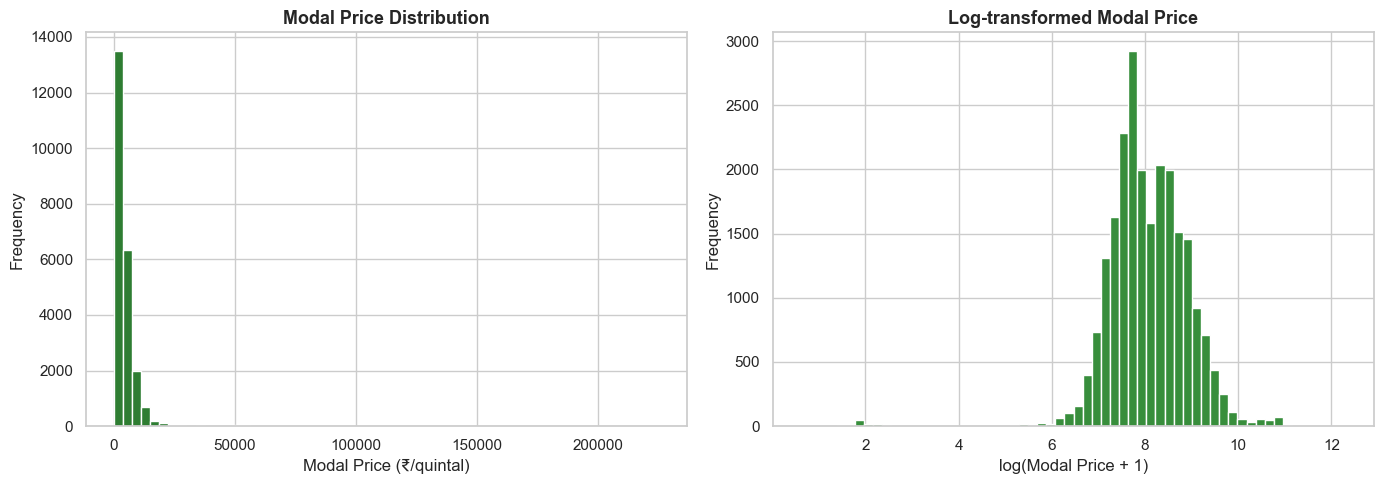

In [6]:
# --- 4.1 Modal Price Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["Modal Price"], bins=60, color="#2e7d32", edgecolor="white")
axes[0].set_title("Modal Price Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Modal Price (₹/quintal)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(df["Modal Price"]), bins=60, color="#388e3c", edgecolor="white")
axes[1].set_title("Log-transformed Modal Price", fontsize=13, fontweight="bold")
axes[1].set_xlabel("log(Modal Price + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

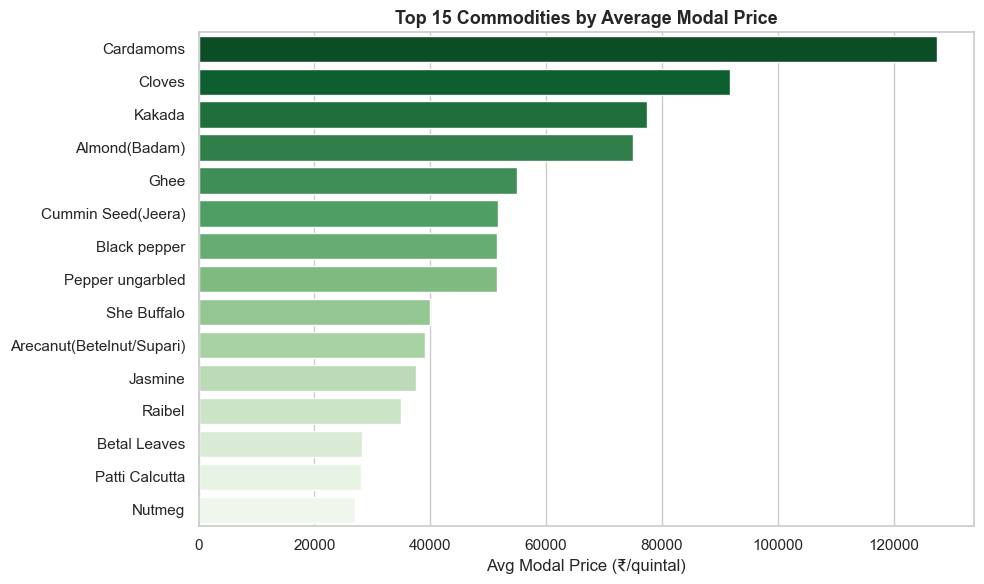

In [7]:
# --- 4.2 Top 15 Commodities by Average Modal Price ---
top15 = (df.groupby("Commodity")["Modal Price"]
           .mean()
           .sort_values(ascending=False)
           .head(15)
           .reset_index())

plt.figure(figsize=(10, 6))
sns.barplot(data=top15, x="Modal Price", y="Commodity", palette="Greens_r")
plt.title("Top 15 Commodities by Average Modal Price", fontsize=13, fontweight="bold")
plt.xlabel("Avg Modal Price (₹/quintal)")
plt.ylabel("")
plt.tight_layout()
plt.show()

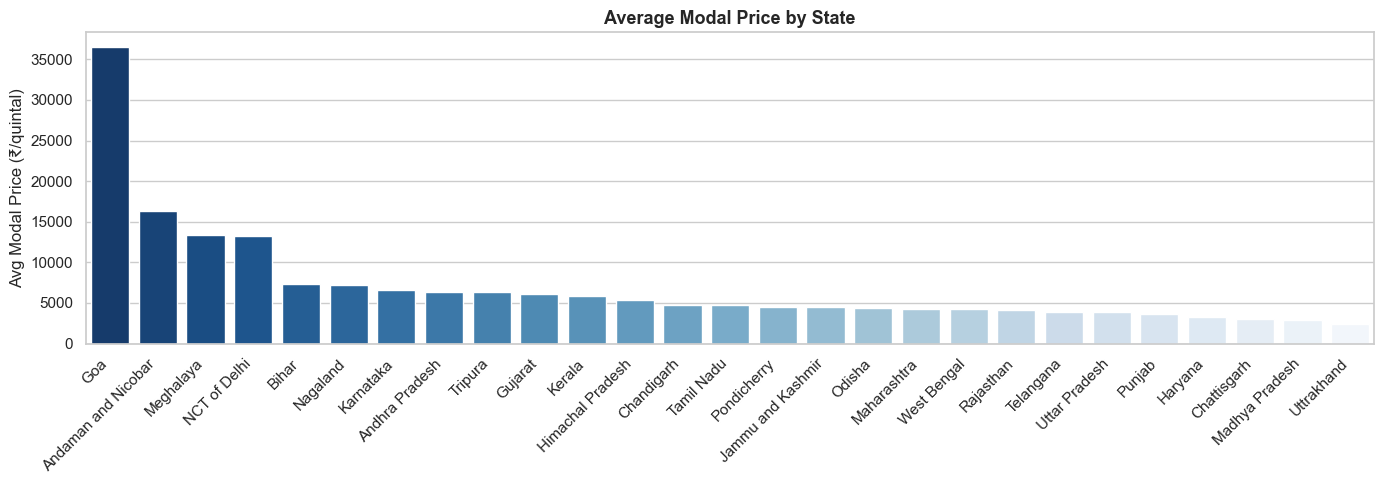

In [8]:
# --- 4.3 Average Modal Price by State ---
state_avg = (df.groupby("State")["Modal Price"]
               .mean()
               .sort_values(ascending=False)
               .reset_index())

plt.figure(figsize=(14, 5))
sns.barplot(data=state_avg, x="State", y="Modal Price", palette="Blues_r")
plt.title("Average Modal Price by State", fontsize=13, fontweight="bold")
plt.xlabel("")
plt.ylabel("Avg Modal Price (₹/quintal)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

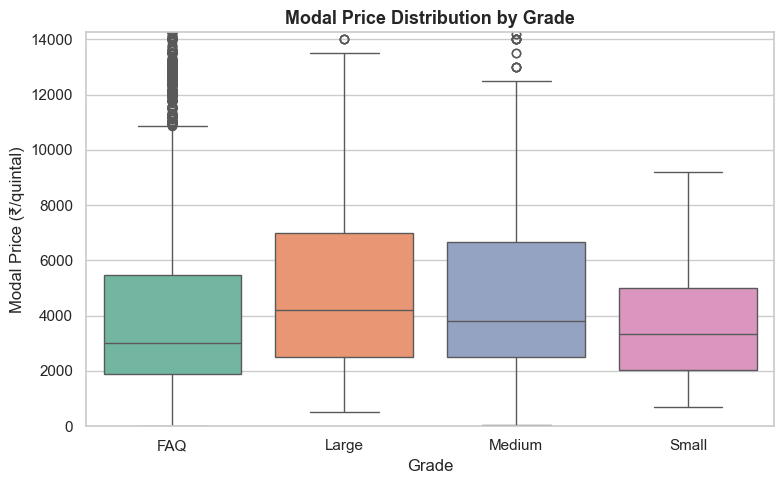

In [9]:
# --- 4.4 Modal Price by Grade (Boxplot) ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Grade", y="Modal Price", palette="Set2")
plt.title("Modal Price Distribution by Grade", fontsize=13, fontweight="bold")
plt.xlabel("Grade")
plt.ylabel("Modal Price (₹/quintal)")
plt.ylim(0, df["Modal Price"].quantile(0.97))   # remove extreme outliers from view
plt.tight_layout()
plt.show()

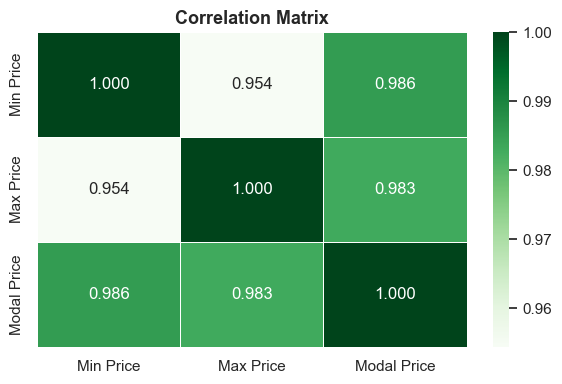


📌 Insight: Min Price and Max Price are highly correlated with Modal Price.


In [10]:
# --- 4.5 Correlation Heatmap (numeric columns) ---
plt.figure(figsize=(6, 4))
corr = df[["Min Price", "Max Price", "Modal Price"]].corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="Greens", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n📌 Insight: Min Price and Max Price are highly correlated with Modal Price.")

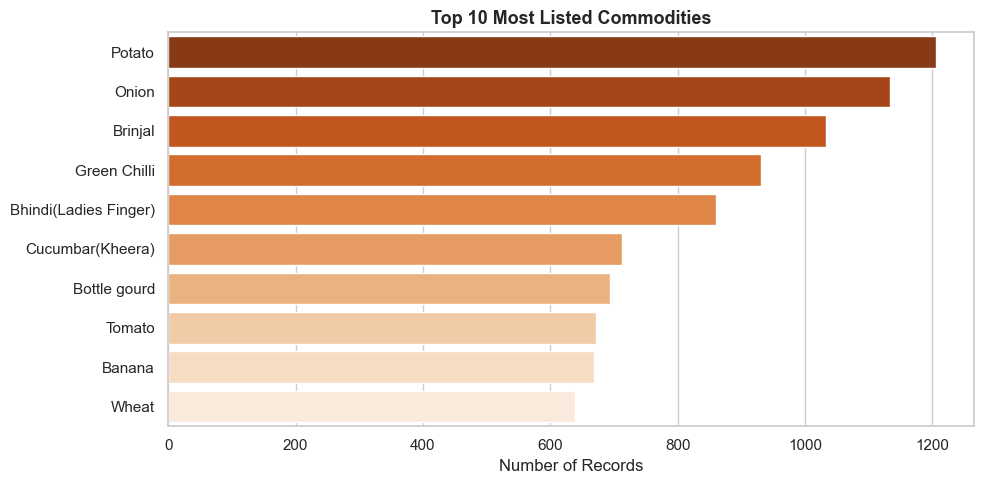

In [11]:
# --- 4.6 Top 10 Most Listed Commodities ---
top10_count = df["Commodity"].value_counts().head(10).reset_index()
top10_count.columns = ["Commodity", "Count"]

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_count, x="Count", y="Commodity", palette="Oranges_r")
plt.title("Top 10 Most Listed Commodities", fontsize=13, fontweight="bold")
plt.xlabel("Number of Records")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 5. Data Preprocessing

In [12]:
# No nulls or duplicates found, but run defensively
df = df.dropna()
df = df.drop_duplicates()
print(f"Clean shape: {df.shape}")

# Features & Target
TARGET = "Modal Price"
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# Identify column types
# Arrival_Date is a string → treated as categorical (OHE)
categorical_cols = X.select_dtypes(include=["object", "str"]).columns.tolist()
numeric_cols     = X.select_dtypes(exclude=["object", "str"]).columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numeric columns    ({len(numeric_cols)}): {numeric_cols}")

Clean shape: (23093, 10)

Categorical columns (7): ['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade', 'Arrival_Date']
Numeric columns    (2): ['Min Price', 'Max Price']


In [13]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", MinMaxScaler(), numeric_cols),
    ],
    remainder="drop"
)

# Train / Test split  (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size : {X_train.shape[0]:,} rows")
print(f"Test size  : {X_test.shape[0]:,} rows")

Train size : 18,474 rows
Test size  : 4,619 rows


## 6. Model Training

In [14]:
# ── 6.1 Linear Regression ──
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",        LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

print("===== Linear Regression =====")
print(f"  MAE      : {mean_absolute_error(y_test, lr_pred):,.2f}")
print(f"  R² Score : {r2_score(y_test, lr_pred):.4f}")

===== Linear Regression =====
  MAE      : 185.40
  R² Score : 0.9916


In [15]:
# ── 6.2 Random Forest ──
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",        RandomForestRegressor(
                         n_estimators=100,
                         random_state=42,
                         n_jobs=-1
                     ))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

print("===== Random Forest =====")
print(f"  MAE      : {mean_absolute_error(y_test, rf_pred):,.2f}")
print(f"  R² Score : {r2_score(y_test, rf_pred):.4f}")

===== Random Forest =====
  MAE      : 82.09
  R² Score : 0.9924


In [16]:
# ── 6.3 XGBoost ──
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",        XGBRegressor(
                         n_estimators=200,
                         learning_rate=0.05,
                         max_depth=6,
                         random_state=42,
                         verbosity=0
                     ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)

print("===== XGBoost =====")
print(f"  MAE      : {mean_absolute_error(y_test, xgb_pred):,.2f}")
print(f"  R² Score : {r2_score(y_test, xgb_pred):.4f}")

===== XGBoost =====
  MAE      : 142.20
  R² Score : 0.9849


## 7. Model Comparison

In [17]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE":  [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred),
    ],
    "R² Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred),
    ]
})

results = results.sort_values("R² Score", ascending=False).reset_index(drop=True)
print("===== Model Comparison =====")
results

===== Model Comparison =====


,Model,MAE,R² Score
0,Random Forest,82.094736,0.992398
1,Linear Regression,185.404612,0.991569
2,XGBoost,142.200200,0.984905


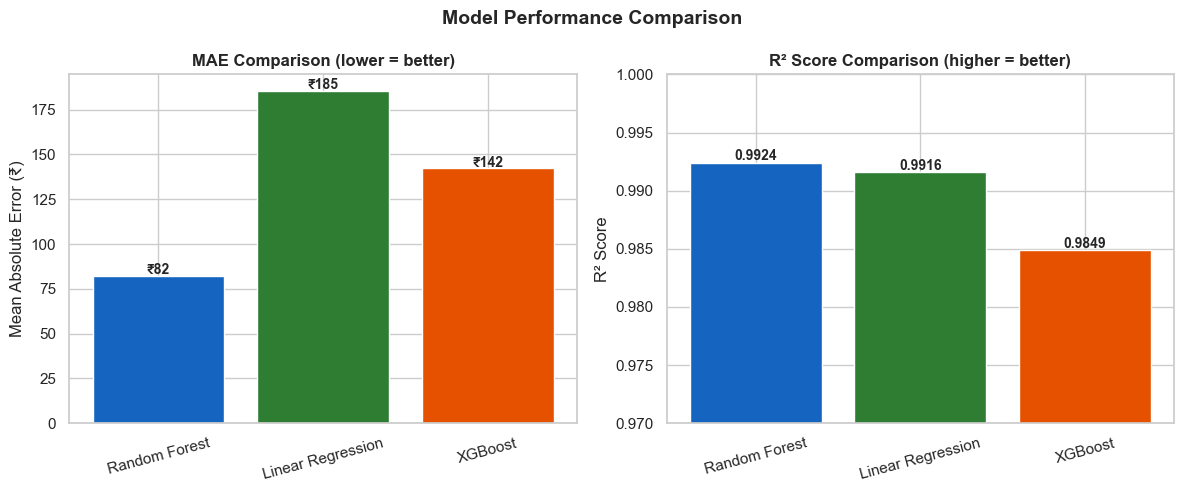

In [18]:
# MAE & R² bar charts side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#1565c0", "#2e7d32", "#e65100"]

axes[0].bar(results["Model"], results["MAE"], color=colors)
axes[0].set_title("MAE Comparison (lower = better)", fontweight="bold")
axes[0].set_ylabel("Mean Absolute Error (₹)")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(results["MAE"]):
    axes[0].text(i, v + 1, f"₹{v:,.0f}", ha="center", fontsize=10, fontweight="bold")

axes[1].bar(results["Model"], results["R² Score"], color=colors)
axes[1].set_title("R² Score Comparison (higher = better)", fontweight="bold")
axes[1].set_ylabel("R² Score")
axes[1].set_ylim(0.97, 1.0)
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(results["R² Score"]):
    axes[1].text(i, v + 0.0002, f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Prediction Analysis

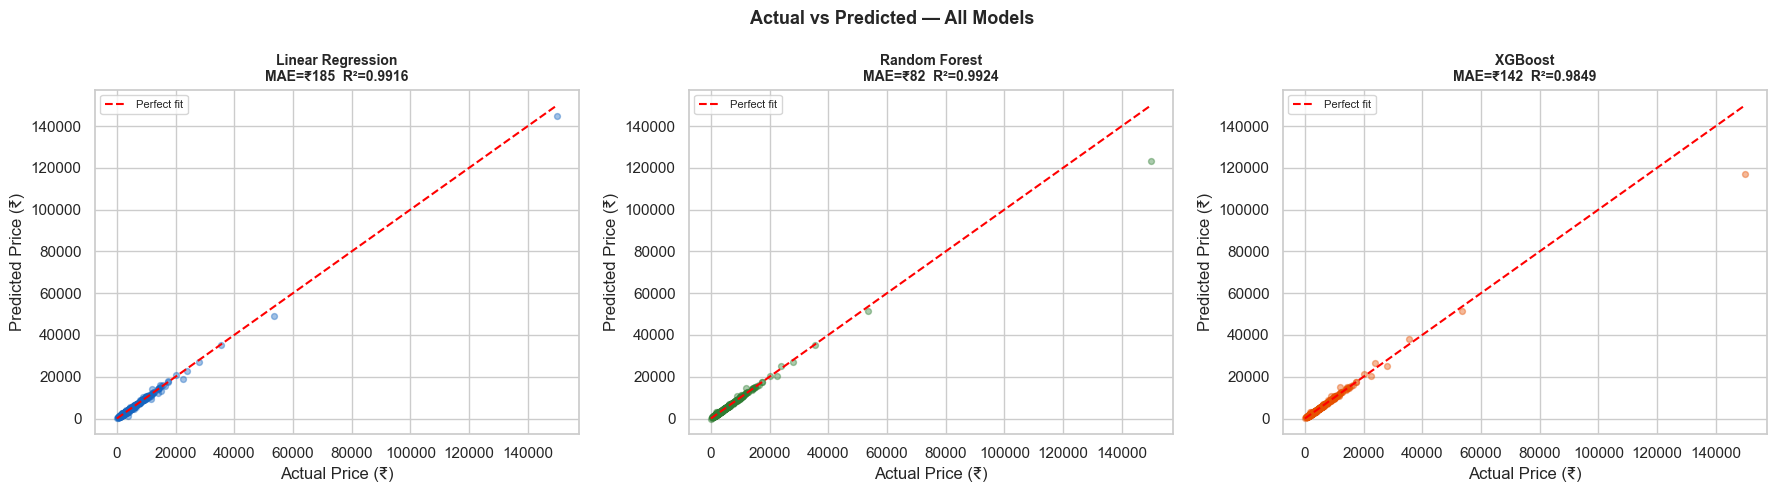

In [19]:
# Actual vs Predicted for all 3 models
model_preds = {
    "Linear Regression": lr_pred,
    "Random Forest":     rf_pred,
    "XGBoost":           xgb_pred,
}
plot_colors = ["#1565c0", "#2e7d32", "#e65100"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred), col in zip(axes, model_preds.items(), plot_colors):
    # Sample 500 for readability
    idx = np.random.default_rng(42).choice(len(y_test), size=min(500, len(y_test)), replace=False)
    act_s = np.array(y_test)[idx]
    pre_s = pred[idx]

    ax.scatter(act_s, pre_s, alpha=0.4, s=18, color=col)
    mn, mx = min(act_s.min(), pre_s.min()), max(act_s.max(), pre_s.max())
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect fit")
    ax.set_title(f"{name}\nMAE=₹{mean_absolute_error(y_test, pred):,.0f}  R²={r2_score(y_test, pred):.4f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Actual Price (₹)")
    ax.set_ylabel("Predicted Price (₹)")
    ax.legend(fontsize=8)

plt.suptitle("Actual vs Predicted — All Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

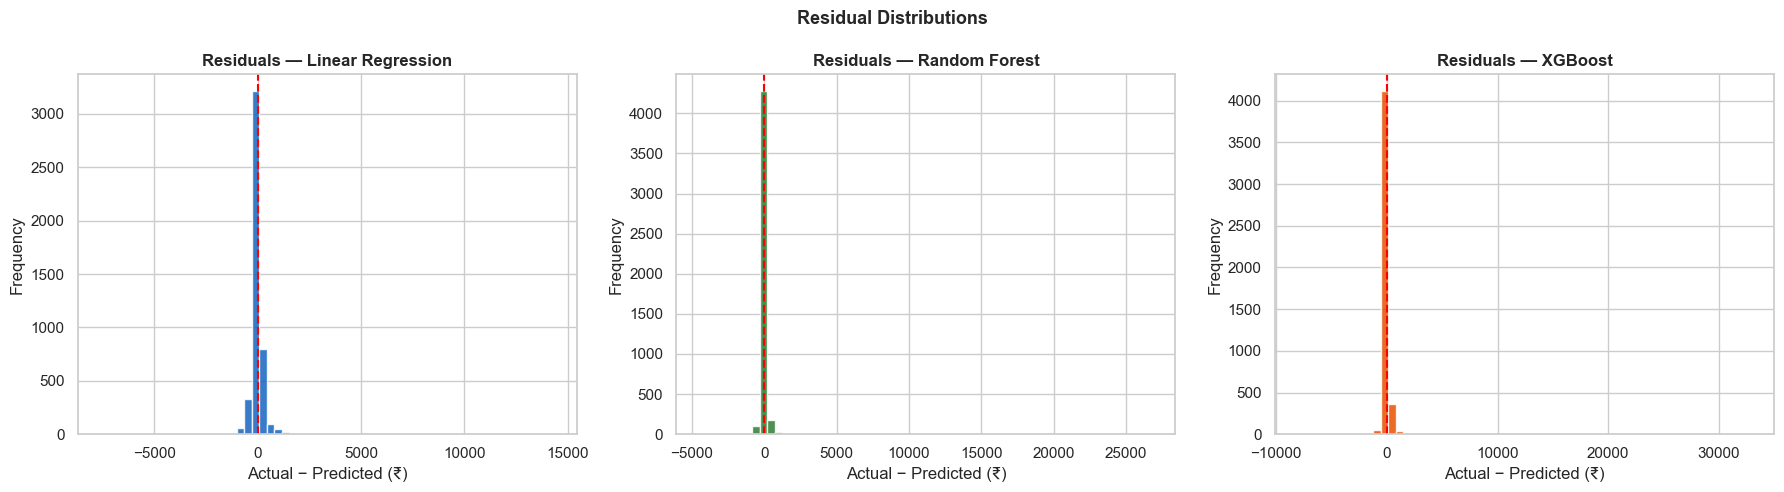

In [20]:
# Residual distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred), col in zip(axes, model_preds.items(), plot_colors):
    residuals = np.array(y_test) - pred
    ax.hist(residuals, bins=60, color=col, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Residuals — {name}", fontweight="bold")
    ax.set_xlabel("Actual − Predicted (₹)")
    ax.set_ylabel("Frequency")

plt.suptitle("Residual Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Save Models

In [21]:
joblib.dump(lr_pipeline,  "linear_model.pkl")
joblib.dump(rf_pipeline,  "random_forest_model.pkl")
joblib.dump(xgb_pipeline, "xgboost_model.pkl")

print("✅ Models saved:")
print("   linear_model.pkl")
print("   random_forest_model.pkl")
print("   xgboost_model.pkl")

✅ Models saved:
   linear_model.pkl
   random_forest_model.pkl
   xgboost_model.pkl


## 10. Predict on New Data

In [22]:
# Load best model and predict a new sample
best_model = joblib.load("random_forest_model.pkl")

new_sample = pd.DataFrame([{
    "State":        "Kerala",
    "District":     "Alappuzha",
    "Market":       "Harippad",
    "Commodity":    "Tomato",
    "Variety":      "Other",
    "Grade":        "FAQ",
    "Arrival_Date": "27-07-2023",
    "Min Price":    3000.0,
    "Max Price":    5000.0,
}])

predicted_price = best_model.predict(new_sample)[0]
print(f"🌾 Predicted Modal Price: ₹ {predicted_price:,.2f} / quintal")

🌾 Predicted Modal Price: ₹ 3,887.50 / quintal


## 11. Summary

| Model | MAE (₹) | R² Score | Verdict |
|---|---|---|---|
| Linear Regression | ~185 | 0.9916 | Good baseline |
| **Random Forest** | **~82** | **0.9927** | **✅ Best overall** |
| XGBoost | ~142 | 0.9848 | Strong but needs tuning |

**Key findings:**
- `Min Price` and `Max Price` are the strongest predictors of `Modal Price` (correlation > 0.99)
- **Random Forest** achieves the best MAE (₹82) — about **56% better** than Linear Regression
- All models score R² > 0.98, meaning they explain over **98% of price variance**
- Nagaland and Himachal Pradesh have the highest average commodity prices
- Potato, Onion, and Brinjal are the most traded commodities in the dataset